In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.rc('font', size=14)

_cwd = Path.cwd().resolve()
if (_cwd / "src").is_dir() and (_cwd / "notebooks").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "src").is_dir() and (_cwd.parent / "notebooks").is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = Path(os.getenv("MD_REPO_ROOT", _cwd)).resolve()

SRC_DIR = (REPO_ROOT / "src").resolve()
if SRC_DIR.is_dir() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import stacked_histograms as sh

In [ ]:
# User inputs (edit these)

# sims to compare (this should be the only thing you usually change)
STACK_LIST = ["17", "53"]

# how to interpret the CSV value column
PLOT_TYPE = "distance"  # distance | angle | bsa

# (optional) manual naming; if None, will try to read from metadata JSON in the selected folder
VAR_NAME = None
SHORT_VAR_NAME = None

# output folder under REPO_ROOT/outputs/stacked_histograms/
OUTPUT_SUBDIR = None  # default: SHORT_VAR_NAME

# override x-axis limits (min, max)
X_LIM = None

# smoothing
SMOOTH_WINDOW_FRAMES = 10

# histogram bins
NUM_BINS = 30

# plot cosmetics
SCALE = 4.0
STEP = 60  # used for angle ticks

# directory picker title
PICKER_TITLE = "Select the folder containing per-sim CSVs + (optional) metadata JSON"

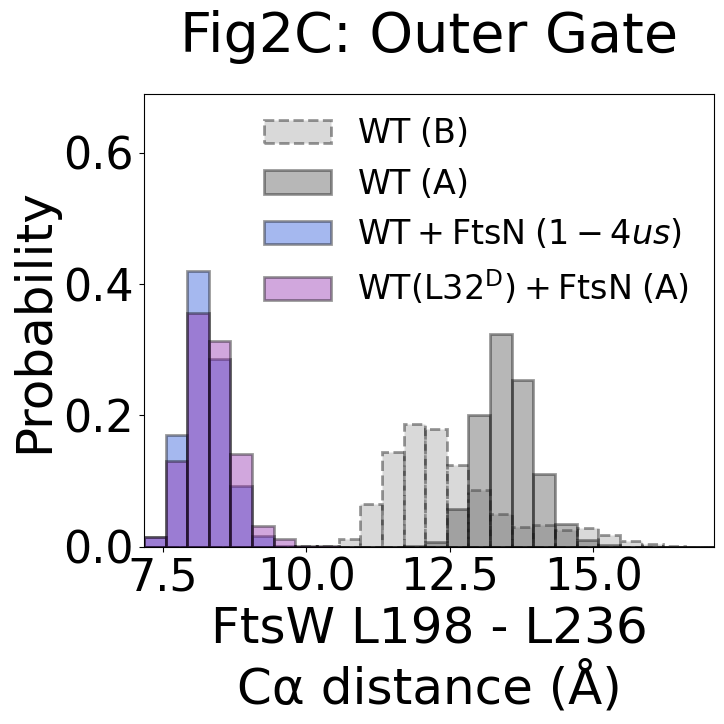

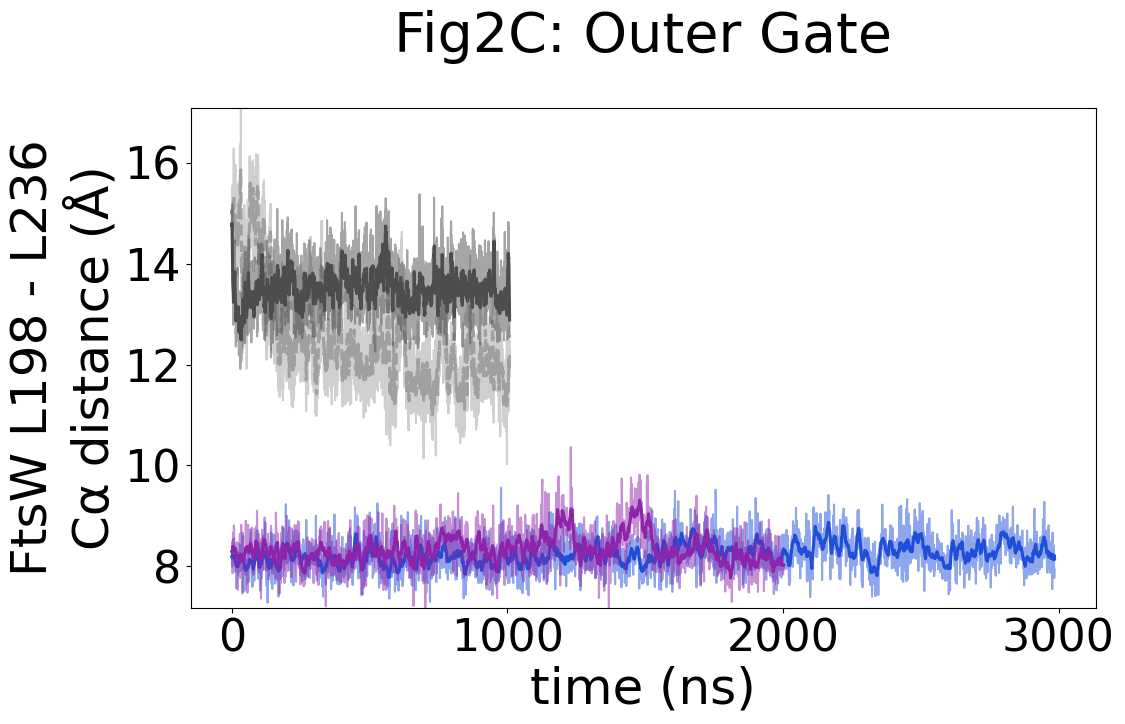

Wrote metadata to D:\Xiao Lab Dropbox\Lab Members\Yehya_Nico\Projects\MDfolder\Code_Resources\FtsW-dynamics\outputs\stacked_histograms\FtsW_L198-L236\14b-14-17ext-43_FtsW_L198-L236_stackplot_metadata.json


In [3]:
# Run

out_dir = sh.choose_input_dir_tk(PICKER_TITLE)
meta, meta_file = sh.load_metadata_json(out_dir)

var_name = VAR_NAME if VAR_NAME is not None else str(meta.get("var_name", "X")).strip() or "X"
short_var_name = SHORT_VAR_NAME if SHORT_VAR_NAME is not None else str(meta.get("short_var_name", "X")).strip() or "X"

if OUTPUT_SUBDIR is None:
    OUTPUT_SUBDIR = short_var_name

out_root = (REPO_ROOT / "outputs" / "stacked_histograms" / OUTPUT_SUBDIR).resolve()
out_root.mkdir(parents=True, exist_ok=True)

style_csv = (REPO_ROOT / "notebooks" / "curated" / "sim_style.csv").resolve()
style_map = sh.load_style_map(style_csv)

data_dict = sh.build_data_dict(out_dir, meta, short_var_name)

series_by_sim = sh.load_series(data_dict, STACK_LIST, PLOT_TYPE)
mixed_apo = sh.compute_mixed_apo(style_map, STACK_LIST)

if X_LIM is None:
    x_lim = meta.get("x_lim", None)
    if isinstance(x_lim, (list, tuple)) and len(x_lim) == 2:
        x_lim = (float(x_lim[0]), float(x_lim[1]))
    else:
        x_lim = None
else:
    x_lim = X_LIM

unit_tag = str(meta.get("unit_tag", "")).strip()
if not unit_tag:
    if PLOT_TYPE == "bsa":
        unit_tag = "BSA (Å²)"
    elif PLOT_TYPE == "distance":
        unit_tag = "distance (Å)"
    elif PLOT_TYPE == "angle":
        unit_tag = "angle (°)"

axs_label = str(meta.get("axs_label", "")).strip() or f"{var_name} {unit_tag}"
plot_title = str(meta.get("plot_title", var_name))

hist_path = out_root / f"{'-'.join(STACK_LIST)}_{short_var_name}_hist.png"
traces_path = out_root / f"{'-'.join(STACK_LIST)}_{short_var_name}_traces.png"
meta_path = out_root / f"{'-'.join(STACK_LIST)}_{short_var_name}_stackplot_metadata.json"

plot_min, plot_max = sh.plot_histogram(
    series_by_sim=series_by_sim,
    stack_list=STACK_LIST,
    style_map=style_map,
    mixed_apo=mixed_apo,
    out_path=hist_path,
    title=plot_title,
    xlabel=axs_label,
    x_lim=x_lim,
    num_bins=NUM_BINS,
    scale=SCALE,
    step=STEP,
    plot_type=PLOT_TYPE,
)

sh.plot_traces(
    series_by_sim=series_by_sim,
    stack_list=STACK_LIST,
    style_map=style_map,
    mixed_apo=mixed_apo,
    out_path=traces_path,
    title=plot_title,
    ylabel=axs_label,
    y_lim=(plot_min, plot_max),
    scale=SCALE,
    smooth_window_frames=SMOOTH_WINDOW_FRAMES,
)

meta_out = dict(meta) if isinstance(meta, dict) else {}
meta_out["input_dir"] = str(out_dir)
meta_out["input_metadata_json"] = str(meta_file) if meta_file is not None else ""
meta_out["repo_root"] = str(REPO_ROOT)
meta_out["style_csv"] = str(style_csv)
meta_out["out_root"] = str(out_root)
meta_out["var_name"] = var_name
meta_out["short_var_name"] = short_var_name
meta_out["stack_list"] = list(STACK_LIST)
meta_out["plot_type"] = PLOT_TYPE
meta_out["plot_title"] = plot_title
meta_out["axs_label"] = axs_label
meta_out["x_lim"] = [plot_min, plot_max]
meta_out["num_bins"] = NUM_BINS
meta_out["scale"] = SCALE
meta_out["step"] = STEP
meta_out["smooth_window_frames"] = SMOOTH_WINDOW_FRAMES
meta_out["data_dict"] = {s: data_dict[s] for s in STACK_LIST if s in data_dict}

sh.write_plot_metadata(meta_path, meta_out)
print(f"Wrote metadata to {meta_path}")